# B17 — Multi-Qubit Circuits and Ordering

**Track B — the SDK.** This notebook is here to save you an afternoon.

---

## The one-sentence version

Qiskit is **little-endian**: statevector index $i$ is the bitstring with **qubit 0
as the rightmost character**. The textbook construction `np.kron(q0, q1)` is
**big-endian**. Nothing raises when you mix them — you just get a different state
than the one you meant, and every downstream number is quietly wrong.

## Why this costs people a day

Three readings of the same register are in play at once, and two of them run
left-to-right while one runs the other way:

| what you're looking at | reading order |
|---|---|
| `qc.draw()` — the circuit diagram | **top to bottom**: qubit 0 is the *top* wire |
| `Statevector` / counts — the bitstring | **right to left**: qubit 0 is the *rightmost* character |
| `np.kron(a, b)` — the tensor chain | **left to right**: the *left* factor owns the *high* bit |

So the first wire you draw is the last character you read. That is the whole
trap. There is no physics in it — it is pure convention — but conventions that
disagree *silently* cost far more debugging time than most physics does, because
the failure is a wrong number rather than a stack trace.

A05 established this convention for Track A from first principles. This notebook
checks, in Qiskit, that the choice was the right one, shows exactly what the
wrong choice looks like, and hands you one figure (the **Rosetta table**) to come
back to whenever you lose your footing.

## What we will do

1. Run the one experiment that settles the convention: `X` on qubit 0.
2. Read `QuantumRegister` layout and `find_bit` so multi-register circuits hold
   no surprises.
3. Build the state the naive way, watch it disagree, then fix it.
4. Do the same for `Operator(qc).data` — where the textbook CNOT matrix turns out
   to be the *other* CNOT.
5. Check how counts keys are ordered, and where the classical register enters.
6. Note the **third** ordering nobody warns you about: transpiler layout.

In [1]:
from qviz import backends, grid, style

from functools import reduce

import matplotlib.pyplot as plt
import numpy as np
import qiskit
from matplotlib.patches import Rectangle
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ClassicalRegister, QuantumRegister
from qiskit.primitives import StatevectorSampler
from qiskit.quantum_info import Operator, Statevector

style.use()

SEED = backends.seed_for("B17")
rng = np.random.default_rng(SEED)
print("qiskit", qiskit.__version__, " seed", SEED)

# The single-qubit vocabulary, as raw matrices. Track B may use quantum_info,
# but the whole point of this notebook is comparing SDK output against a
# hand-built array, so the arrays have to be visible.
I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
H = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)
S = np.array([[1, 0], [0, 1j]], dtype=complex)

qiskit 2.5.1  seed 20260821


## 1. The experiment that settles it

One gate, one qubit, and the answer is not open to interpretation. Apply $X$ to
**qubit 0** of a 2-qubit register and ask Qiskit which index lit up.

In [2]:
probe = QuantumCircuit(2)
probe.x(0)

sv_probe = Statevector(probe)
hit = int(np.argmax(np.abs(sv_probe.data)))

print("X on qubit 0 of QuantumCircuit(2)")
print("  amplitudes      :", np.round(sv_probe.data.real, 3))
print("  non-zero index  :", hit)
print("  Qiskit prints it:", list(sv_probe.probabilities_dict()))
print()
print("index 1 = binary 01. The '1' is the RIGHTMOST character, and it is qubit 0.")
print("Little-endian, confirmed by the library rather than by memory.")

# Same question on three qubits: X on qubit k must land on index 2**k.
for k in range(3):
    c = QuantumCircuit(3)
    c.x(k)
    idx = int(np.argmax(np.abs(Statevector(c).data)))
    print(f"  X on qubit {k} of 3 -> index {idx:>1} = 2**{k}, "
          f"printed |{format(idx, '03b')}>")

X on qubit 0 of QuantumCircuit(2)
  amplitudes      : [0. 1. 0. 0.]
  non-zero index  : 1
  Qiskit prints it: [np.str_('01')]

index 1 = binary 01. The '1' is the RIGHTMOST character, and it is qubit 0.
Little-endian, confirmed by the library rather than by memory.
  X on qubit 0 of 3 -> index 1 = 2**0, printed |001>
  X on qubit 1 of 3 -> index 2 = 2**1, printed |010>
  X on qubit 2 of 3 -> index 4 = 2**2, printed |100>


### Figure 1 — where the confusion actually comes from

Left: the circuit as Qiskit draws it. Qubit 0 is the **top** wire — that is the
universal circuit-diagram convention and Qiskit follows it.

Right: the same three qubits, connected to the characters of the printed
bitstring. The lines cross, and that crossing *is* the bug. The diagram is read
top-to-bottom, the bitstring is read left-to-right, and the two orders run
opposite to each other in qubit index.

Nothing is wrong with either convention on its own. The cost is entirely in the
translation between them.

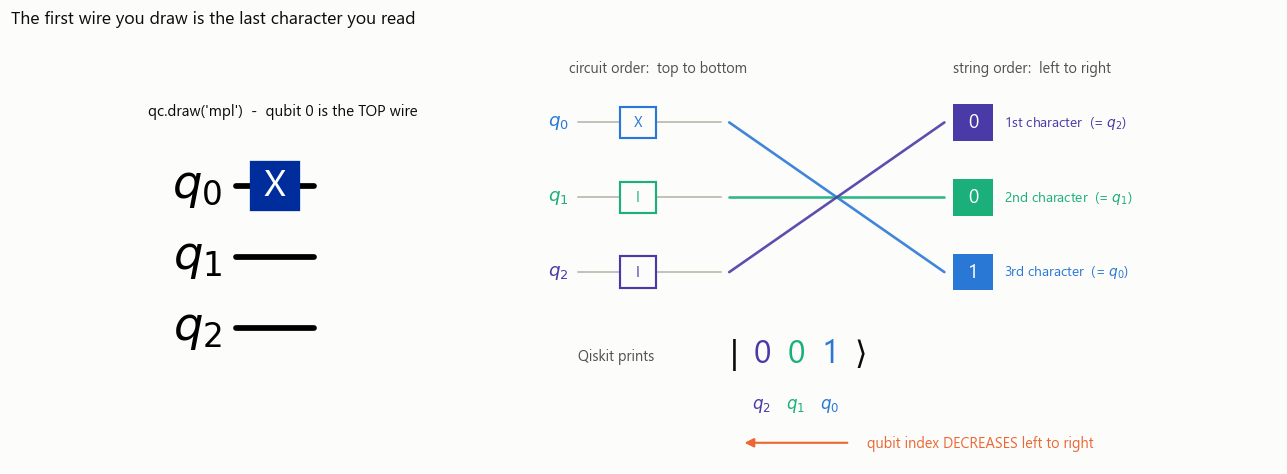

In [3]:
demo = QuantumCircuit(3)
demo.x(0)
bitstr = format(int(np.argmax(np.abs(Statevector(demo).data))), "03b")

# The mpl circuit drawer sets an equal aspect ratio and then fills whatever axes
# it is given, so a full-height panel renders the wire labels enormous. Boxing it
# into the middle row of a 3-row column is what keeps it in proportion.
fig = plt.figure(figsize=(11.6, 4.2))
gs = fig.add_gridspec(3, 2, width_ratios=[0.80, 1.40],
                      height_ratios=[0.22, 1.0, 0.22], wspace=0.04, hspace=0.0)
axC = fig.add_subplot(gs[1, 0])
axX = fig.add_subplot(gs[:, 1])

demo.draw("mpl", ax=axC, style={"backgroundcolor": style.SURFACE})
axC.set_title("qc.draw('mpl')  -  qubit 0 is the TOP wire", loc="left",
              fontsize=10)

# ---- the crossing diagram
axX.set_axis_off()
axX.set_xlim(0, 11.6)
axX.set_ylim(-2.55, 3.15)

WIRE_X0, WIRE_X1 = 1.35, 3.45
CHAR_X = 7.15
qcols = [style.BLUE, style.AQUA, style.VIOLET]

for k in range(3):
    y = 2 - k                                   # qubit 0 on top, like the circuit
    axX.plot([WIRE_X0, WIRE_X1], [y, y], color=style.AXIS, lw=1.3, zorder=2)
    axX.text(WIRE_X0 - 0.14, y, f"$q_{k}$", fontsize=12, ha="right", va="center",
             color=qcols[k])
    axX.add_patch(Rectangle((WIRE_X0 + 0.62, y - 0.21), 0.52, 0.42,
                            facecolor=style.SURFACE, edgecolor=qcols[k], lw=1.4,
                            zorder=3))
    axX.text(WIRE_X0 + 0.88, y, "X" if k == 0 else "I", fontsize=9.5,
             ha="center", va="center", color=qcols[k], zorder=4)

    # character j of the printed string belongs to qubit n-1-j, so qubit k sits
    # at character j = 2-k, drawn at row y = 2 - j = k.  Hence the crossing.
    yc = k
    axX.plot([WIRE_X1 + 0.12, CHAR_X - 0.42], [y, yc], color=qcols[k], lw=1.7,
             alpha=0.9, zorder=2,
             solid_capstyle="round")
    axX.add_patch(Rectangle((CHAR_X - 0.30, yc - 0.245), 0.60, 0.49,
                            facecolor=qcols[k], edgecolor="none", zorder=3))
    axX.text(CHAR_X, yc, bitstr[2 - k], fontsize=12.5, ha="center", va="center",
             color="white", zorder=4, weight="medium")
    ordinal = ["1st", "2nd", "3rd"][2 - k]
    axX.text(CHAR_X + 0.46, yc, f"{ordinal} character  (= $q_{k}$)", fontsize=9,
             ha="left", va="center", color=qcols[k])

axX.text(WIRE_X0 - 0.14, 2.72, "circuit order:  top to bottom", fontsize=9.5,
         ha="left", va="center", color=style.INK_2)
axX.text(CHAR_X - 0.30, 2.72, "string order:  left to right", fontsize=9.5,
         ha="left", va="center", color=style.INK_2)

# ---- the printed ket underneath, drawn character by character so the qubit
# tags below can be positioned exactly under their digit.
axX.text(1.35, -1.12, "Qiskit prints", fontsize=9.5, ha="left", va="center",
         color=style.INK_2)
DIG_X = [4.05, 4.55, 5.05]                 # leftmost character first
axX.text(DIG_X[0] - 0.44, -1.10, r"$|$", fontsize=21, ha="center", va="center",
         color=style.INK)
axX.text(DIG_X[2] + 0.44, -1.10, r"$\rangle$", fontsize=21, ha="center",
         va="center", color=style.INK)
for j, xk in enumerate(DIG_X):
    axX.text(xk, -1.10, bitstr[j], fontsize=21, ha="center", va="center",
             color=qcols[2 - j])
    axX.text(xk, -1.78, f"$q_{2 - j}$", fontsize=11, ha="center", va="center",
             color=qcols[2 - j])
axX.annotate("", xy=(DIG_X[0] - 0.30, -2.28), xytext=(DIG_X[2] + 0.30, -2.28),
             arrowprops=dict(arrowstyle="-|>", color=style.ORANGE, lw=1.4,
                             mutation_scale=12))
axX.text(DIG_X[2] + 0.55, -2.28, "qubit index DECREASES left to right",
         fontsize=9.5, ha="left", va="center", color=style.ORANGE)

fig.suptitle("The first wire you draw is the last character you read",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

## 2. `QuantumRegister` layout — what index is this qubit?

`QuantumCircuit(3)` quietly builds a `QuantumRegister(3, "q")`. Once you declare
registers yourself — which this repo does, so the primitive result attribute is
predictable — the qubits are laid out in **declaration order**, and the global
index is what everything else keys off.

`qc.find_bit(bit)` is the authoritative lookup. Use it instead of counting.

In [4]:
a = QuantumRegister(2, "a")
b = QuantumRegister(3, "b")
cr = ClassicalRegister(5, "c")
multi = QuantumCircuit(a, b, cr)

print("registers in declaration order:", [r.name for r in multi.qregs])
print()
for bit in multi.qubits:
    loc = multi.find_bit(bit)
    reg, off = loc.registers[0]
    print(f"  global index {loc.index}   <- {reg.name}[{off}]   "
          f"= character {multi.num_qubits - 1 - loc.index} from the left")

print()
print("a[0] is global qubit 0, so it is the RIGHTMOST character of a 5-bit key.")
print("b[2] is global qubit 4, so it is the LEFTMOST.")

# Prove it rather than assert it by eye.
chk = QuantumCircuit(a, b)
chk.x(b[2])
print("\nX on b[2] ->", list(Statevector(chk).probabilities_dict()),
      " (global index", int(np.argmax(np.abs(Statevector(chk).data))), ")")

registers in declaration order: ['a', 'b']

  global index 0   <- a[0]   = character 4 from the left
  global index 1   <- a[1]   = character 3 from the left
  global index 2   <- b[0]   = character 2 from the left
  global index 3   <- b[1]   = character 1 from the left
  global index 4   <- b[2]   = character 0 from the left

a[0] is global qubit 0, so it is the RIGHTMOST character of a 5-bit key.
b[2] is global qubit 4, so it is the LEFTMOST.

X on b[2] -> [np.str_('10000')]  (global index 16 )


## 3. The wrong construction, and why it never complains

Here is the code almost everyone writes first. It is the direct transcription of
$|\psi\rangle = |q_0\rangle \otimes |q_1\rangle$, which is how the state is
written in most textbooks:

```python
psi = np.kron(q0, q1)          # big-endian
Xq0 = np.kron(X, np.eye(2))    # "X on qubit 0"
```

It runs. It returns a normalised 4-vector. It is a perfectly good simulator — of
a **big-endian** machine. Against Qiskit it is wrong on every state that is not
symmetric under reversing the qubits, and right on every state that is, which is
precisely why it survives your first few tests.

The fix is one `[::-1]`: the Kronecker chain is written in **reverse** qubit
order, so qubit 0 comes last.

In [5]:
def register_le(*qubit_states):
    """Join single-qubit states, qubit 0 given FIRST. Little-endian (A05)."""
    return reduce(np.kron, qubit_states[::-1])


def op_on_le(U, k, n):
    """Embed a 2x2 U on qubit k of n. Qubit 0 is the RIGHTMOST kron factor."""
    ops = [I2] * n
    ops[k] = np.asarray(U, dtype=complex)
    return reduce(np.kron, ops[::-1])


def op_on_be(U, k, n):
    """The naive textbook embedding: read the chain left to right. BIG-endian."""
    ops = [I2] * n
    ops[k] = np.asarray(U, dtype=complex)
    return reduce(np.kron, ops)


e00 = np.zeros(4, dtype=complex)
e00[0] = 1.0

qiskit_sv = Statevector(probe).data          # X on qubit 0, from the SDK
little = op_on_le(X, 0, 2) @ e00
big = op_on_be(X, 0, 2) @ e00

print("Qiskit                     :", np.round(qiskit_sv.real, 3),
      " -> index", int(np.argmax(np.abs(qiskit_sv))))
print("little-endian  kron(I, X)  :", np.round(little.real, 3),
      " -> index", int(np.argmax(np.abs(little))))
print("big-endian     kron(X, I)  :", np.round(big.real, 3),
      " -> index", int(np.argmax(np.abs(big))))
print()
print("little-endian matches Qiskit:", np.allclose(little, qiskit_sv))
print("big-endian    matches Qiskit:", np.allclose(big, qiskit_sv),
      "   <- no exception, no warning, just a different state")

# The symmetric-state trap, in two lines: both conventions agree here.
KET0 = np.array([1, 0], dtype=complex)
PLUS = np.array([1, 1], dtype=complex) / np.sqrt(2)
bell = np.array([1, 0, 0, 1], dtype=complex) / np.sqrt(2)
print("\nand on a SYMMETRIC state the bug is invisible:")
print("  |+>|+>  agrees :", np.allclose(np.kron(PLUS, PLUS), register_le(PLUS, PLUS)))
print("  Bell    agrees :", np.allclose(bell, bell[::-1]))
print("  |0>|+>  agrees :", np.allclose(np.kron(KET0, PLUS), register_le(PLUS, KET0)),
      "  <- and here it is caught")

Qiskit                     : [0. 1. 0. 0.]  -> index 1
little-endian  kron(I, X)  : [0. 1. 0. 0.]  -> index 1
big-endian     kron(X, I)  : [0. 0. 1. 0.]  -> index 2

little-endian matches Qiskit: True
big-endian    matches Qiskit: False    <- no exception, no warning, just a different state

and on a SYMMETRIC state the bug is invisible:
  |+>|+>  agrees : True
  Bell    agrees : True
  |0>|+>  agrees : True   <- and here it is caught


### Figure 2 — the wrong answer, struck through

The README promises this picture, so here it is without hedging. Same intent,
same one-line change, two different physical states.

The top panel is what `np.kron(X, np.eye(2))` returns. The bottom panel is what
Qiskit returns. Neither computation failed.

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
C:\Users\thoma\AppData\Local\Temp\ipykernel_26324\1234695002.py:4: SyntaxWarning: invalid escape sequence '\s'
  matplotlib has no strikethrough, and mathtext has no \sout. Measure the


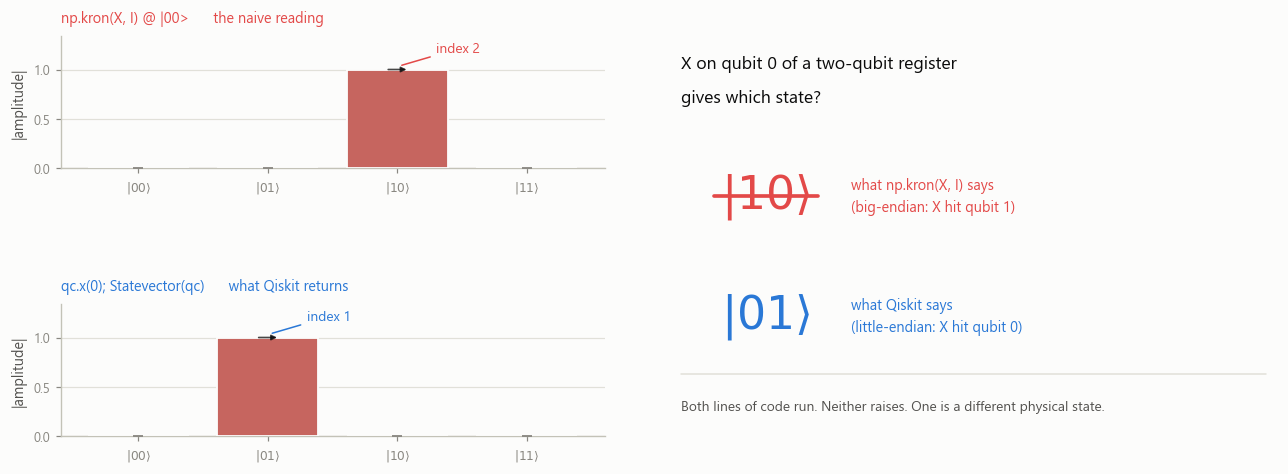

In [6]:
def strike(ax, artist, *, color, pad=0.012, lw=2.4):
    """Draw a strikethrough across a text artist, in data coordinates.

    matplotlib has no strikethrough, and mathtext has no \sout. Measure the
    rendered extent once the canvas exists, convert it back to data space, and
    draw a line through the middle. Kept inline because qviz is frozen.
    """
    ax.figure.canvas.draw()
    bb = artist.get_window_extent().transformed(ax.transData.inverted())
    y = 0.5 * (bb.y0 + bb.y1)
    ax.plot([bb.x0 - pad, bb.x1 + pad], [y, y], color=color, lw=lw,
            solid_capstyle="round", zorder=10, clip_on=False)


fig = plt.figure(figsize=(11.6, 4.2))
gs = fig.add_gridspec(2, 2, width_ratios=[1.0, 1.12], hspace=0.18, wspace=0.10)
axW = fig.add_subplot(gs[0, 0])
axR = fig.add_subplot(gs[1, 0])
axV = fig.add_subplot(gs[:, 1])

for ax, vec, head, col in [
        (axW, big, "np.kron(X, I) @ |00>      the naive reading", style.RED),
        (axR, qiskit_sv, "qc.x(0); Statevector(qc)      what Qiskit returns",
         style.BLUE)]:
    grid.amp_bars(ax, vec, ylim=1.34, ylabel="|amplitude|")
    ax.set_title(head, loc="left", fontsize=9.5, color=col)
    j = int(np.argmax(np.abs(vec)))
    ax.annotate(f"index {j}", xy=(j, 1.03), xytext=(j + 0.30, 1.21), fontsize=9,
                color=col, ha="left", va="center",
                arrowprops=dict(arrowstyle="-", color=col, lw=1.0, shrinkA=2,
                                shrinkB=3))

# ---- the verdict
axV.set_axis_off()
axV.set_xlim(0, 1)
axV.set_ylim(0, 1)
axV.text(0.02, 0.93, "X on qubit 0 of a two-qubit register", fontsize=11.5,
         color=style.INK, va="center")
axV.text(0.02, 0.845, "gives which state?", fontsize=11.5, color=style.INK,
         va="center")

wrong = axV.text(0.16, 0.60, grid.ket("10"), fontsize=30, color=style.RED,
                 ha="center", va="center")
strike(axV, wrong, color=style.RED)
axV.text(0.30, 0.60, "what np.kron(X, I) says\n(big-endian: X hit qubit 1)",
         fontsize=9.5, color=style.RED, ha="left", va="center", linespacing=1.5)

axV.text(0.16, 0.30, grid.ket("01"), fontsize=30, color=style.BLUE,
         ha="center", va="center")
axV.text(0.30, 0.30, "what Qiskit says\n(little-endian: X hit qubit 0)",
         fontsize=9.5, color=style.BLUE, ha="left", va="center", linespacing=1.5)

axV.plot([0.02, 0.98], [0.155, 0.155], color=style.GRID, lw=1.0)
axV.text(0.02, 0.075, "Both lines of code run. Neither raises. One is a "
                      "different physical state.",
         fontsize=9, color=style.INK_2, ha="left", va="center")
plt.show()

## 4. The Rosetta table

This is the figure to bookmark. For every statevector index of a 3-qubit
register it shows the printed bitstring and then, side by side, what each
convention says the individual qubits are doing.

Read a row as: *"index 3 is printed `011`. Qiskit says qubit 0 = 1, qubit 1 = 1,
qubit 2 = 0. The big-endian reading says qubit 0 = 0, qubit 1 = 1, qubit 2 = 1."*

The shaded rows are where the two disagree — four of eight here, and in general
every index whose bit pattern is not a palindrome. Those are the states on which
a big-endian simulator silently parts company with Qiskit.

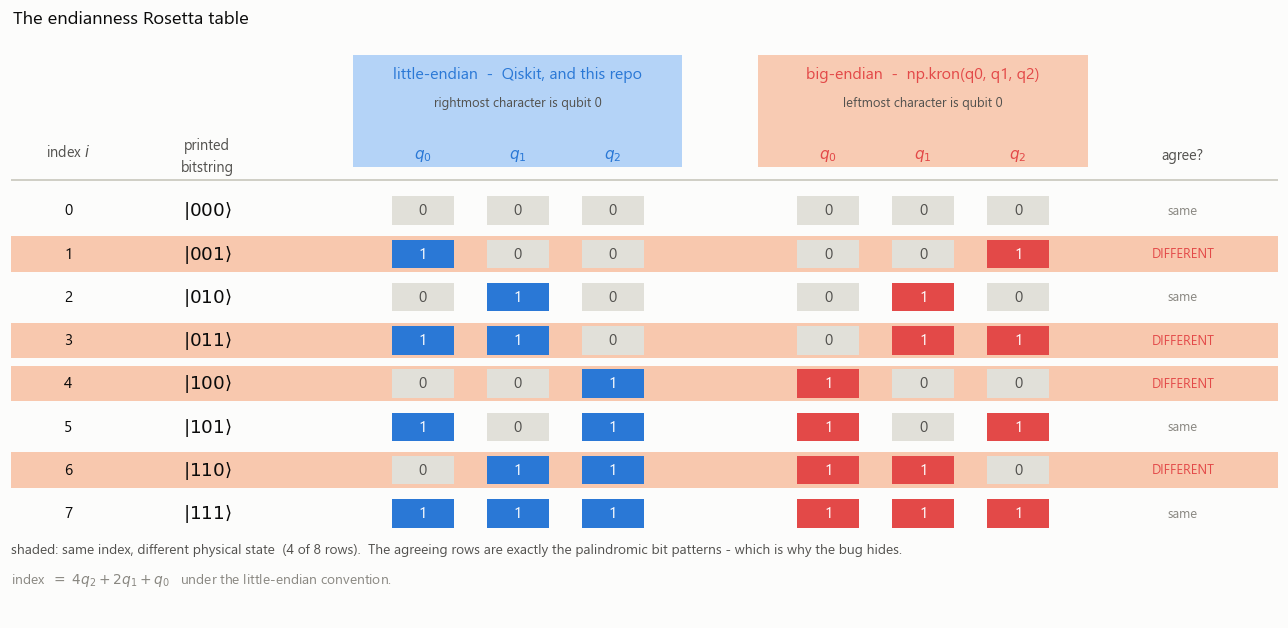

index 0  |000>   little (q0,q1,q2)=(0, 0, 0)   big (q0,q1,q2)=(0, 0, 0)
index 1  |001>   little (q0,q1,q2)=(1, 0, 0)   big (q0,q1,q2)=(0, 0, 1)   <- differ
index 2  |010>   little (q0,q1,q2)=(0, 1, 0)   big (q0,q1,q2)=(0, 1, 0)
index 3  |011>   little (q0,q1,q2)=(1, 1, 0)   big (q0,q1,q2)=(0, 1, 1)   <- differ
index 4  |100>   little (q0,q1,q2)=(0, 0, 1)   big (q0,q1,q2)=(1, 0, 0)   <- differ
index 5  |101>   little (q0,q1,q2)=(1, 0, 1)   big (q0,q1,q2)=(1, 0, 1)
index 6  |110>   little (q0,q1,q2)=(0, 1, 1)   big (q0,q1,q2)=(1, 1, 0)   <- differ
index 7  |111>   little (q0,q1,q2)=(1, 1, 1)   big (q0,q1,q2)=(1, 1, 1)


In [7]:
N_Q = 3
rows = list(range(2 ** N_Q))

fig, ax = plt.subplots(figsize=(11.6, 5.6))
ax.set_axis_off()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

XI, XB = 0.045, 0.155
LX = [0.325, 0.400, 0.475]        # little-endian chips, q0 q1 q2 left to right
BX = [0.645, 0.720, 0.795]        # big-endian chips, same q0 q1 q2 order
XD = 0.925
TOP, DY = 0.700, 0.0745

# ---- group headers
ax.text(np.mean(LX), 0.935, "little-endian  -  Qiskit, and this repo",
        fontsize=10.5, color=style.BLUE, ha="center", va="center",
        weight="medium")
ax.text(np.mean(LX), 0.885, "rightmost character is qubit 0", fontsize=8.5,
        color=style.INK_2, ha="center", va="center")
ax.text(np.mean(BX), 0.935, "big-endian  -  np.kron(q0, q1, q2)",
        fontsize=10.5, color=style.RED, ha="center", va="center",
        weight="medium")
ax.text(np.mean(BX), 0.885, "leftmost character is qubit 0", fontsize=8.5,
        color=style.INK_2, ha="center", va="center")

ax.add_patch(Rectangle((LX[0] - 0.055, 0.775), LX[2] - LX[0] + 0.110, 0.192,
                       facecolor=style.SEQ(0.06), edgecolor="none", zorder=0))
ax.add_patch(Rectangle((BX[0] - 0.055, 0.775), BX[2] - BX[0] + 0.110, 0.192,
                       facecolor=style.SEQ2(0.08), edgecolor="none", zorder=0))

# ---- column headers
ax.text(XI, 0.800, "index $i$", fontsize=9.5, color=style.INK_2, ha="center",
        va="center")
ax.text(XB, 0.812, "printed", fontsize=9.5, color=style.INK_2, ha="center",
        va="center")
ax.text(XB, 0.775, "bitstring", fontsize=9.5, color=style.INK_2, ha="center",
        va="center")
for xs, col in [(LX, style.BLUE), (BX, style.RED)]:
    for j, x in enumerate(xs):
        ax.text(x, 0.795, f"$q_{j}$", fontsize=10, color=col, ha="center",
                va="center")
ax.text(XD, 0.795, "agree?", fontsize=9.5, color=style.INK_2, ha="center",
        va="center")
ax.plot([0.0, 1.0], [0.752, 0.752], color=style.AXIS, lw=1.0)

# ---- rows
n_differ = 0
for r, i in enumerate(rows):
    y = TOP - r * DY
    bits = format(i, f"0{N_Q}b")                     # b_{n-1} ... b_0
    le_vals = [(i >> k) & 1 for k in range(N_Q)]     # qubit k <- bit k
    be_vals = [int(bits[k]) for k in range(N_Q)]     # qubit k <- character k
    differ = le_vals != be_vals
    n_differ += differ
    if differ:
        ax.add_patch(Rectangle((0.0, y - 0.0305), 1.0, 0.061,
                               facecolor=style.SEQ2(0.09), edgecolor="none",
                               zorder=0))
    ax.text(XI, y, str(i), fontsize=10, color=style.INK, ha="center",
            va="center")
    ax.text(XB, y, grid.ket(bits), fontsize=12, color=style.INK, ha="center",
            va="center")
    for xs, vals, col in [(LX, le_vals, style.BLUE), (BX, be_vals, style.RED)]:
        for j, x in enumerate(xs):
            on = vals[j] == 1
            ax.add_patch(Rectangle((x - 0.0245, y - 0.0245), 0.049, 0.049,
                                   facecolor=col if on else style.GRID,
                                   edgecolor="none", zorder=2))
            ax.text(x, y, str(vals[j]), fontsize=10, ha="center", va="center",
                    color="white" if on else style.INK_2, zorder=3)
    ax.text(XD, y, "same" if not differ else "DIFFERENT", fontsize=8.5,
            ha="center", va="center",
            color=style.MUTED if not differ else style.RED,
            weight="normal" if not differ else "medium")

ax.text(0.0, TOP - 7 * DY - 0.062,
        f"shaded: same index, different physical state  "
        f"({n_differ} of {2 ** N_Q} rows).  The agreeing rows are exactly the "
        f"palindromic bit patterns - which is why the bug hides.",
        fontsize=9, color=style.INK_2, va="center")
ax.text(0.0, TOP - 7 * DY - 0.115,
        "index  $=\\;4q_2 + 2q_1 + q_0$   under the little-endian convention.",
        fontsize=9, color=style.MUTED, va="center")
fig.suptitle("The endianness Rosetta table", x=0.005, ha="left", fontsize=12)
plt.show()

for i in rows:
    bits = format(i, "03b")
    le_vals = tuple((i >> k) & 1 for k in range(3))
    be_vals = tuple(int(bits[k]) for k in range(3))
    flag = "" if le_vals == be_vals else "   <- differ"
    print(f"index {i}  |{bits}>   little (q0,q1,q2)={le_vals}   "
          f"big (q0,q1,q2)={be_vals}{flag}")

## 5. `Operator(qc).data` — where the textbook CNOT is the other CNOT

Everything above was about states. Operators inherit the same convention, and
here the mismatch has a memorable form.

Open any textbook and you find CNOT written as

$$\mathrm{CNOT} = \begin{pmatrix}1&0&0&0\\0&1&0&0\\0&0&0&1\\0&0&1&0\end{pmatrix}.$$

Ask Qiskit for `Operator(qc)` after `qc.cx(0, 1)` and you get a *different*
matrix. Neither is wrong. In the little-endian convention that textbook matrix
swaps indices 2 and 3, i.e. it flips **qubit 0 when qubit 1 is set** — it is
`cx(1, 0)`, control and target exchanged.

The safe way to build a controlled gate by hand is from its truth table on
indices, never by transcribing sixteen numbers.

In [8]:
def cx_le(control, target, n):
    """CNOT on an n-qubit little-endian register, built from the index rule.

    Basis index j has qubit k in bit k of j. So: if bit `control` of j is set,
    flip bit `target`. No matrix is transcribed and no kron order is guessed.
    """
    D = 2 ** n
    M = np.zeros((D, D), dtype=complex)
    for j in range(D):
        M[j ^ (((j >> control) & 1) << target), j] = 1.0
    return M


TEXTBOOK_CNOT = np.array([[1, 0, 0, 0],
                          [0, 1, 0, 0],
                          [0, 0, 0, 1],
                          [0, 0, 1, 0]], dtype=complex)

cx01 = QuantumCircuit(2)
cx01.cx(0, 1)
cx10 = QuantumCircuit(2)
cx10.cx(1, 0)

U01 = Operator(cx01).data
U10 = Operator(cx10).data

print("Operator(cx(0,1)) ==")
print(U01.real.astype(int))
print()
print("matches cx_le(0, 1, 2)          :", np.allclose(U01, cx_le(0, 1, 2)))
print("matches the TEXTBOOK CNOT matrix:", np.allclose(U01, TEXTBOOK_CNOT))
print("the textbook matrix is really   : cx(1, 0)  ->",
      np.allclose(TEXTBOOK_CNOT, U10))
print()
print("reverse_qargs() converts between the two readings:")
print("  Operator(cx(0,1)).reverse_qargs() == textbook :",
      np.allclose(Operator(cx01).reverse_qargs().data, TEXTBOOK_CNOT))
print("  Statevector(x(0)).reverse_qargs()             :",
      np.round(Statevector(probe).reverse_qargs().data.real, 3),
      "  (index 2, i.e. the big-endian answer)")

Operator(cx(0,1)) ==
[[1 0 0 0]
 [0 0 0 1]
 [0 0 1 0]
 [0 1 0 0]]

matches cx_le(0, 1, 2)          : True
matches the TEXTBOOK CNOT matrix: False
the textbook matrix is really   : cx(1, 0)  -> True

reverse_qargs() converts between the two readings:
  Operator(cx(0,1)).reverse_qargs() == textbook : True
  Statevector(x(0)).reverse_qargs()             : [0. 0. 1. 0.]   (index 2, i.e. the big-endian answer)


### Figure 3 — three matrices, two of which are equal

The left panel is what Qiskit gives you for `cx(0, 1)`. The middle is the
textbook matrix. The right is `cx(1, 0)` — and it is the middle one.

Look at where the off-diagonal pair sits. In the left panel it swaps indices 1
and 3 (`01` and `11`): the states where **qubit 0** is set. In the other two it
swaps 2 and 3 (`10` and `11`): the states where **qubit 1** is set.

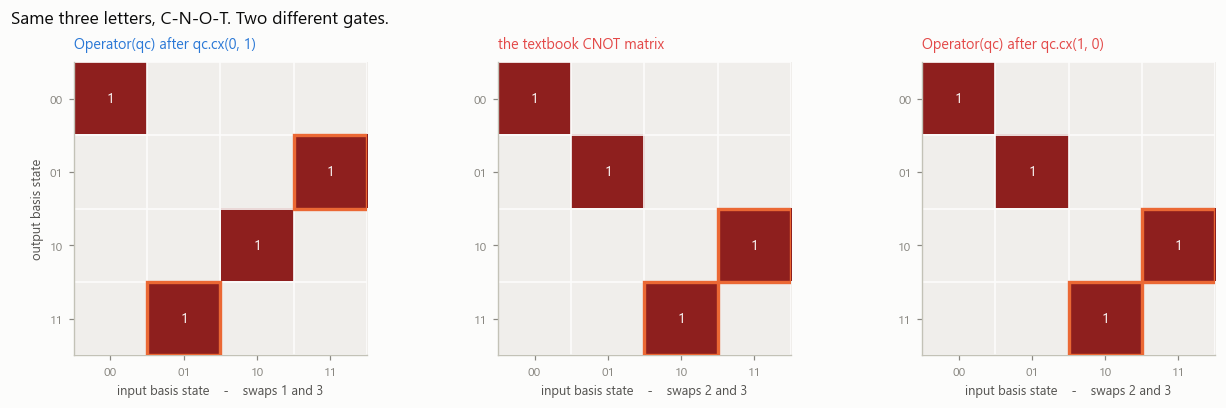

panel 2 equals panel 3 : True
panel 1 equals panel 2 : False


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(11.6, 3.6))
panels = [
    (U01, "Operator(qc) after qc.cx(0, 1)", style.BLUE),
    (TEXTBOOK_CNOT, "the textbook CNOT matrix", style.RED),
    (U10, "Operator(qc) after qc.cx(1, 0)", style.RED),
]
for ax, (M, name, col) in zip(axes, panels):
    grid.matrix(ax, M, part="re", cbar=False, annot=True, vmax=1.0,
                fmt="{:.0f}", annot_size=9)
    ax.set_title(name, loc="left", fontsize=9.5, color=col)
    ax.set_xlabel("input basis state", fontsize=8.5)
axes[0].set_ylabel("output basis state", fontsize=8.5)

# Ring the two off-diagonal entries in each panel: that pair IS the difference.
for ax, (p, q) in zip(axes, [(1, 3), (2, 3), (2, 3)]):
    for r, c in [(p, q), (q, p)]:
        ax.add_patch(Rectangle((c - 0.5, r - 0.5), 1, 1, facecolor="none",
                               edgecolor=style.ORANGE, lw=2.2, zorder=6))
    ax.set_xlabel(f"input basis state    -    swaps {p} and {q}", fontsize=8.5)

fig.suptitle("Same three letters, C-N-O-T. Two different gates.",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

print("panel 2 equals panel 3 :", np.allclose(TEXTBOOK_CNOT, U10))
print("panel 1 equals panel 2 :", np.allclose(U01, TEXTBOOK_CNOT))

The same story plays out for single-qubit gates embedded in a
larger register. `Operator(qc)` for `qc.h(1)` on three qubits is
$I \otimes H \otimes I$ — which happens to be symmetric, so pick qubit 2 instead
and the difference becomes visible immediately.

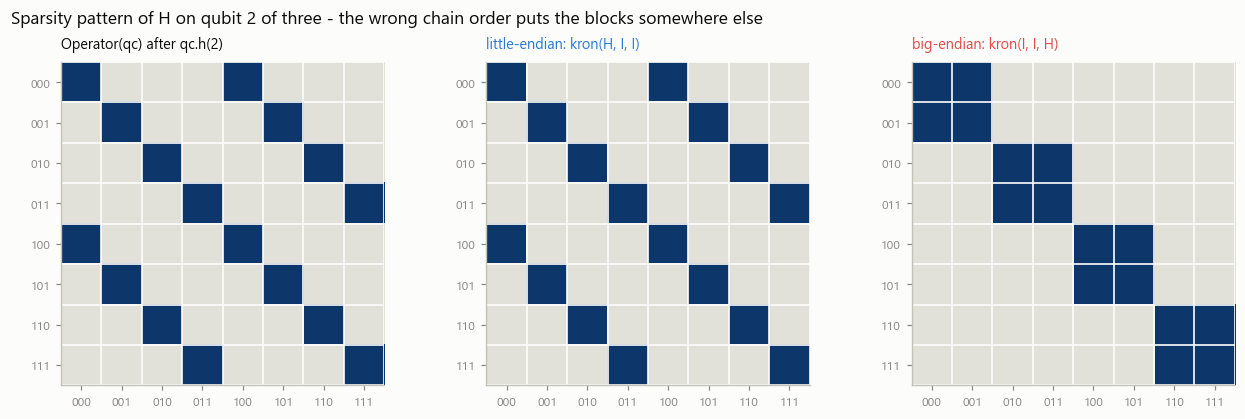

Qiskit == little-endian kron : True
Qiskit == big-endian kron    : False
the big-endian build is actually H on qubit 0: True


In [10]:
emb = QuantumCircuit(3)
emb.h(2)
U_emb = Operator(emb).data

fig, axes = plt.subplots(1, 3, figsize=(11.6, 3.7))
for ax, (M, name, col) in zip(axes, [
        (U_emb, "Operator(qc) after qc.h(2)", style.INK),
        (op_on_le(H, 2, 3), "little-endian: kron(H, I, I)", style.BLUE),
        (op_on_be(H, 2, 3), "big-endian: kron(I, I, H)", style.RED)]):
    grid.matrix(ax, M, part="nonzero", cbar=False)
    ax.set_title(name, loc="left", fontsize=9.5, color=col)

fig.suptitle("Sparsity pattern of H on qubit 2 of three - the wrong chain order "
             "puts the blocks somewhere else",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

print("Qiskit == little-endian kron :", np.allclose(U_emb, op_on_le(H, 2, 3)))
print("Qiskit == big-endian kron    :", np.allclose(U_emb, op_on_be(H, 2, 3)))
print("the big-endian build is actually H on qubit 0:",
      np.allclose(op_on_be(H, 2, 3), op_on_le(H, 0, 3)))

## 6. Counts keys

A counts key is a **classical** bitstring, and it follows the classical register,
not the quantum one. Two rules cover every case:

1. Within a register, **clbit 0 is the rightmost character** — the same
   convention as the statevector.
2. The mapping from qubits to clbits is whatever you wrote in `measure(...)`.
   `qc.measure(qr, cr)` pairs them index for index; anything else is your own
   permutation and Qiskit will faithfully honour it.

Result access goes through the classical register's **name** — `result[0].data.c`
for a `ClassicalRegister(n, "c")`. `measure_all()` names it `meas` instead, which
is a common `AttributeError`.

In [11]:
qr = QuantumRegister(3, "q")
crg = ClassicalRegister(3, "c")
qc_m = QuantumCircuit(qr, crg)
qc_m.h(0)
qc_m.cx(0, 1)
qc_m.x(2)
qc_m.measure(qr, crg)                 # qubit k -> clbit k

SHOTS = 4096
res = StatevectorSampler(seed=SEED).run([qc_m], shots=SHOTS).result()
counts = res[0].data.c.get_counts()   # ".c" = the register's NAME
print("counts:", dict(sorted(counts.items())))

no_meas = qc_m.remove_final_measurements(inplace=False)
analytic = np.abs(Statevector(no_meas).data) ** 2
measured = np.array([counts.get(format(i, "03b"), 0) / SHOTS for i in range(8)])

print("\nnon-zero analytic bins:",
      [(format(i, "03b"), round(float(analytic[i]), 3))
       for i in range(8) if analytic[i] > 1e-9])
print("q2 is 1 in every key: X was applied to qubit 2, the LEFTMOST character.")

# What a big-endian reading would have predicted: the same probabilities,
# assigned to the reversed keys.
be_pred = np.zeros(8)
for i in range(8):
    be_pred[int(format(i, "03b")[::-1], 2)] = analytic[i]

# And the permutation you asked for, if you wire the measurement backwards.
qc_rev = QuantumCircuit(qr, crg)
qc_rev.h(0)
qc_rev.cx(0, 1)
qc_rev.x(2)
qc_rev.measure([qr[0], qr[1], qr[2]], [crg[2], crg[1], crg[0]])
rev_counts = StatevectorSampler(seed=SEED).run(
    [qc_rev], shots=SHOTS).result()[0].data.c.get_counts()
print("\nmeasure(q -> c reversed):", dict(sorted(rev_counts.items())),
      "  same physics, relabelled classically")

counts: {'100': 2071, '111': 2025}

non-zero analytic bins: [('100', 0.5), ('111', 0.5)]
q2 is 1 in every key: X was applied to qubit 2, the LEFTMOST character.

measure(q -> c reversed): {'001': 2071, '111': 2025}   same physics, relabelled classically


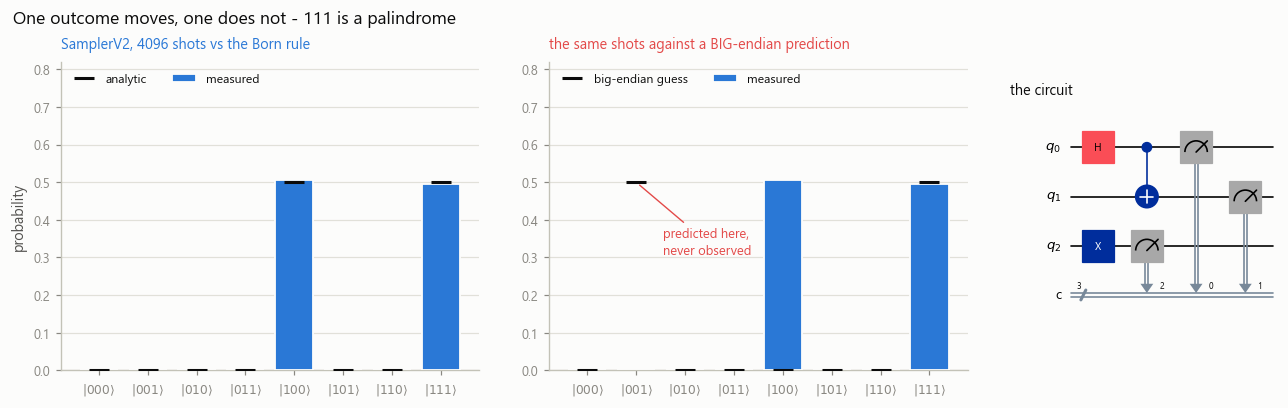

largest deviation from analytic: 0.0056
big-endian prediction is wrong by up to: 0.5056


In [12]:
fig = plt.figure(figsize=(11.6, 3.6))
gs = fig.add_gridspec(1, 3, width_ratios=[1.25, 1.25, 0.80], wspace=0.10)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 2])

grid.prob_bars(ax0, measured, analytic=analytic, ymax_pad=1.62)
ax0.set_title(f"SamplerV2, {SHOTS} shots vs the Born rule", loc="left",
              fontsize=9.5, color=style.BLUE)
ax0.legend(loc="upper left", ncol=2, fontsize=8)

grid.prob_bars(ax1, measured, analytic=be_pred, ymax_pad=1.62)
ax1.set_title("the same shots against a BIG-endian prediction", loc="left",
              fontsize=9.5, color=style.RED)
ax1.set_ylabel("")
# prob_bars names its artists "measured"/"analytic"; matplotlib hands back lines
# before patches, so relabel by NAME rather than by position.
rename = {"analytic": "big-endian guess", "measured": "measured"}
h, lab = ax1.get_legend_handles_labels()
ax1.legend(h, [rename[x] for x in lab], loc="upper left", ncol=2, fontsize=8)
for i in range(8):
    if be_pred[i] > 1e-9 and measured[i] < 1e-9:
        ax1.annotate("predicted here,\nnever observed", xy=(i, be_pred[i]),
                     xytext=(i + 0.55, be_pred[i] - 0.16), fontsize=8.5,
                     color=style.RED, ha="left", va="center", linespacing=1.4,
                     arrowprops=dict(arrowstyle="-", color=style.RED, lw=0.9,
                                     shrinkA=2, shrinkB=3))

qc_m.draw("mpl", ax=ax2, style={"backgroundcolor": style.SURFACE})
ax2.set_title("the circuit", loc="left", fontsize=9.5)

fig.suptitle("One outcome moves, one does not - 111 is a palindrome",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

print("largest deviation from analytic:",
      round(float(np.abs(measured - analytic).max()), 4))
print("big-endian prediction is wrong by up to:",
      round(float(np.abs(measured - be_pred).max()), 4))

## 7. The escape hatches

When you genuinely need the other order — comparing against a paper, or feeding a
big-endian routine — do not hand-roll the reversal. Qiskit ships it:

| you want | call |
|---|---|
| the circuit drawn with qubit 0 at the bottom | `qc.draw("mpl", reverse_bits=True)` |
| the statevector in big-endian index order | `Statevector(qc).reverse_qargs()` |
| the operator in big-endian index order | `Operator(qc).reverse_qargs()` |
| a state from a bitstring you can read | `Statevector.from_label("011")` |
| probabilities keyed by bitstring | `sv.probabilities_dict()` |

`from_label` is the one worth internalising: it takes the string exactly as
printed, so `Statevector.from_label("011")` is qubit 0 = 1, qubit 1 = 1,
qubit 2 = 0. Writing states as labels rather than as index arithmetic removes
most opportunities to be wrong.

Statevector.from_label('011') -> index 3   qubits (q0,q1,q2) = (1, 1, 0)
register_le(q0, q1, q2) matches from_label: True

reverse_qargs() is a relabelling, not a gate:
  norm preserved          : True
  applied twice = identity: True


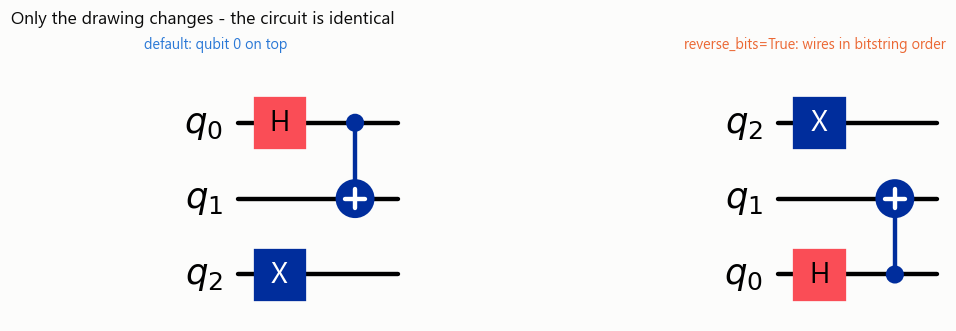

In [13]:
lbl = Statevector.from_label("011")
idx = int(np.argmax(np.abs(lbl.data)))
print("Statevector.from_label('011') -> index", idx,
      "  qubits (q0,q1,q2) =", tuple((idx >> k) & 1 for k in range(3)))

hand = register_le(np.array([0, 1], dtype=complex),      # q0 = 1
                   np.array([0, 1], dtype=complex),      # q1 = 1
                   np.array([1, 0], dtype=complex))      # q2 = 0
print("register_le(q0, q1, q2) matches from_label:", np.allclose(hand, lbl.data))

print("\nreverse_qargs() is a relabelling, not a gate:")
sv3 = Statevector(emb)
print("  norm preserved          :",
      np.isclose(float(np.linalg.norm(sv3.reverse_qargs().data)), 1.0))
print("  applied twice = identity:",
      np.allclose(sv3.reverse_qargs().reverse_qargs().data, sv3.data))

fig, axes = plt.subplots(1, 2, figsize=(9.8, 2.9))
demo2 = QuantumCircuit(3)
demo2.h(0)
demo2.cx(0, 1)
demo2.x(2)
demo2.draw("mpl", ax=axes[0], style={"backgroundcolor": style.SURFACE})
axes[0].set_title("default: qubit 0 on top", loc="left", fontsize=9.5,
                  color=style.BLUE)
demo2.draw("mpl", ax=axes[1], reverse_bits=True,
           style={"backgroundcolor": style.SURFACE})
axes[1].set_title("reverse_bits=True: wires in bitstring order", loc="left",
                  fontsize=9.5, color=style.ORANGE)
fig.suptitle("Only the drawing changes - the circuit is identical",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

## Honest limits

**None of this is physics.** Endianness is a labelling choice, exactly like
big-endian versus little-endian integers on a CPU. No experiment can distinguish
the conventions; every observable probability is identical once you translate.
That is precisely what makes it expensive: a wrong *physical* claim gets caught by
a sanity check, while a wrong *labelling* claim propagates through a whole
notebook producing plausible numbers.

**`reverse_qargs()` is not a SWAP network.** It relabels the axes of an existing
array. If you want to physically exchange two qubits on hardware, that is
`qc.swap(i, j)` and it costs three CNOTs.

**The Rosetta table does not scale.** Eight rows fit on a page; sixteen qubits do
not. Past three or four qubits the only workable habit is to stop reading indices
altogether and use `from_label`, `probabilities_dict()` and `find_bit`.

**And there is a third ordering.** Transpilation introduces a *layout*: the
virtual qubit you wrote as 0 may be assigned to physical qubit 2. The transpiled
circuit's `Statevector` is then in **physical** index order and will not match
your original — even though the convention never changed. `Operator.from_circuit`
knows about the layout and undoes it; plain `Operator` does not. C30 makes
routing and layout its subject; here is just enough to know the trap exists.

In [14]:
orig = QuantumCircuit(2)
orig.x(0)

# Force the layout to swap the two virtual qubits.
tp = transpile(orig, basis_gates=["u", "cx"], coupling_map=[[0, 1], [1, 0]],
               initial_layout=[1, 0], seed_transpiler=SEED)

print("virtual -> physical layout:", tp.layout.final_index_layout())
print("Statevector(original)  :", np.round(Statevector(orig).data.real, 3),
      " -> index", int(np.argmax(np.abs(Statevector(orig).data))))
print("Statevector(transpiled):", np.round(Statevector(tp).data.real, 3),
      " -> index", int(np.argmax(np.abs(Statevector(tp).data))))
print()
print("plain Operator(tp) equals Operator(orig)          :",
      np.allclose(Operator(tp).data, Operator(orig).data))
print("Operator.from_circuit(tp) equals Operator(orig)   :",
      np.allclose(Operator.from_circuit(tp).data, Operator(orig).data),
      "  <- layout-aware")
print()
print("Same convention, same circuit, different index. The transpiler moved the")
print("qubit, not the endianness. Compare with Operator.from_circuit, or")
print("transpile and then read counts through the classical register.")

virtual -> physical layout: [1, 0]
Statevector(original)  : [0. 1. 0. 0.]  -> index 1
Statevector(transpiled): [0. 0. 1. 0.]  -> index 2

plain Operator(tp) equals Operator(orig)          : False
Operator.from_circuit(tp) equals Operator(orig)   : True   <- layout-aware

Same convention, same circuit, different index. The transpiler moved the
qubit, not the endianness. Compare with Operator.from_circuit, or
transpile and then read counts through the classical register.


## Checkpoint

Every Track B notebook closes by asserting `np.allclose` against the Track A
result it mirrors. For B17 that is **A05**, and because endianness *is* the
subject, this cell is the payoff rather than a formality.

We rebuild a deliberately asymmetric three-qubit circuit twice in raw NumPy —
once with A05's little-endian `register`/`op_on` construction, once the naive
big-endian way — and check both against `Statevector(qc).data` and
`Operator(qc).data`. The little-endian build must match. The big-endian build
must **not**, and we assert that too, because a silent agreement there would mean
the test has no teeth. (The failing comparison is caught explicitly: a cell that
raises fails this repo's build gate.)

In [15]:
# ---- A05's constructions, reproduced in raw NumPy (no qiskit on this side).
def cx_be(control, target, n):
    """Naive big-endian CNOT: qubit k is CHARACTER k, i.e. bit n-1-k."""
    D = 2 ** n
    M = np.zeros((D, D), dtype=complex)
    c_bit, t_bit = n - 1 - control, n - 1 - target
    for j in range(D):
        M[j ^ (((j >> c_bit) & 1) << t_bit), j] = 1.0
    return M


N = 3
ket0 = np.eye(2 ** N, dtype=complex)[:, 0]

# The circuit: asymmetric on purpose, so no palindrome can rescue a wrong build.
qc_chk = QuantumCircuit(N)
qc_chk.h(0)
qc_chk.s(0)
qc_chk.x(2)
qc_chk.cx(0, 1)

U_le = cx_le(0, 1, N) @ op_on_le(X, 2, N) @ op_on_le(S, 0, N) @ op_on_le(H, 0, N)
U_be = cx_be(0, 1, N) @ op_on_be(X, 2, N) @ op_on_be(S, 0, N) @ op_on_be(H, 0, N)
psi_le, psi_be = U_le @ ket0, U_be @ ket0

sv_chk = Statevector(qc_chk).data
op_chk = Operator(qc_chk).data

# 1. THE cross-track assertion: A05's little-endian build == Qiskit.
assert np.allclose(psi_le, sv_chk)
assert np.allclose(U_le, op_chk)

# 2. ...and the big-endian build fails the very same assertion. Caught, not
#    raised, so the notebook still executes clean.
for name, arr, target in [("state", psi_be, sv_chk), ("operator", U_be, op_chk)]:
    try:
        assert np.allclose(arr, target)
        raise RuntimeError(f"big-endian {name} agreed - the test has no teeth")
    except AssertionError:
        print(f"big-endian {name} DISAGREES with Qiskit, as it must.")
assert not np.allclose(psi_be, sv_chk)
assert not np.allclose(U_be, op_chk)

# 3. The convention itself: X on qubit k lands on index 2**k.
for n in (2, 3, 4):
    for k in range(n):
        c = QuantumCircuit(n)
        c.x(k)
        assert int(np.argmax(np.abs(Statevector(c).data))) == 2 ** k
        assert np.allclose(Operator(c).data, op_on_le(X, k, n))

# 4. Single-qubit embedding and the hand-checked kron placements (A05 sec. 3).
assert np.allclose(op_on_le(X, 0, 2), np.kron(I2, X))
assert np.allclose(op_on_le(X, 1, 2), np.kron(X, I2))
assert np.allclose(Operator(emb).data, op_on_le(H, 2, 3))
assert np.allclose(op_on_be(H, 2, 3), op_on_le(H, 0, 3))     # off by a mirror

# 5. Controlled gates: the truth-table build matches Qiskit; the textbook
#    matrix is cx(1, 0), not cx(0, 1).
assert np.allclose(U01, cx_le(0, 1, 2))
assert np.allclose(U10, cx_le(1, 0, 2))
assert np.allclose(TEXTBOOK_CNOT, U10)
assert not np.allclose(TEXTBOOK_CNOT, U01)
assert np.allclose(Operator(cx01).reverse_qargs().data, TEXTBOOK_CNOT)

# 6. Register layout: declaration order fixes the global index.
assert [multi.find_bit(bit).index for bit in multi.qubits] == list(range(5))
assert multi.find_bit(b[2]).index == 4

# 7. Labels: from_label reads the string exactly as printed.
assert np.allclose(Statevector.from_label("011").data, hand)
assert int(np.argmax(np.abs(Statevector.from_label("100").data))) == 4

# 8. reverse_qargs is an involution, and it turns each convention into the other.
assert np.allclose(Statevector(probe).reverse_qargs().data, big)
assert np.allclose(Operator(emb).reverse_qargs().data, op_on_be(H, 2, 3))

# 9. Counts follow the classical register, and the shots follow the Born rule.
assert set(counts) <= {format(i, "03b") for i in range(8) if analytic[i] > 1e-9}
assert all(k[0] == "1" for k in counts)            # X on qubit 2 = leftmost char
assert np.abs(measured - analytic).max() < 5 * np.sqrt(0.25 / SHOTS)
assert np.abs(measured - be_pred).max() > 0.3      # the wrong reading is not close
assert sorted(rev_counts) == sorted(k[::-1] for k in counts)

# 10. Transpiler layout is a THIRD ordering, and from_circuit undoes it.
assert not np.allclose(Statevector(tp).data, Statevector(orig).data)
assert np.allclose(Operator.from_circuit(tp).data, Operator(orig).data)

print("\nB17 checkpoint passed - and A05 and Qiskit still agree index for index.")

big-endian state DISAGREES with Qiskit, as it must.
big-endian operator DISAGREES with Qiskit, as it must.

B17 checkpoint passed - and A05 and Qiskit still agree index for index.


---

**What to carry forward.**

1. Qubit 0 is the **rightmost** character. Index $i$ has qubit $k$ in bit $k$.
2. Build multi-qubit operators from the **index rule**, or with the Kronecker
   chain **reversed**. Never transcribe a textbook matrix without checking which
   qubit it controls.
3. When a result looks like a permutation of what you expected, suspect
   endianness first and a bug in the physics second. It is almost always
   endianness.

**Next:** [B18 — Entanglement and Bell States](B18_Entanglement_Bell_States.ipynb),
where the two-qubit states we can now index correctly turn out to be
un-factorable — and we measure exactly how much.